In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/UNSW_NB15_whole.csv')

In [ ]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 257673 entries, 0 to 257672
Data columns (total 44 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   dur                257673 non-null  float64
 1   proto              257673 non-null  object 
 2   service            257673 non-null  object 
 3   state              257673 non-null  object 
 4   spkts              257673 non-null  int64  
 5   dpkts              257673 non-null  int64  
 6   sbytes             257673 non-null  int64  
 7   dbytes             257673 non-null  int64  
 8   rate               257673 non-null  float64
 9   sttl               257673 non-null  int64  
 10  dttl               257673 non-null  int64  
 11  sload              257673 non-null  float64
 12  dload              257673 non-null  float64
 13  sloss              257673 non-null  int64  
 14  dloss              257673 non-null  int64  
 15  sinpkt             257673 non-null  float64
 16  di

,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,0.000011,udp,-,INT,2,0,496,0,90909.0902,254,...,1,2,0,0,0,1,2,0,Normal,0
1,0.000008,udp,-,INT,2,0,1762,0,125000.0003,254,...,1,2,0,0,0,1,2,0,Normal,0
2,0.000005,udp,-,INT,2,0,1068,0,200000.0051,254,...,1,3,0,0,0,1,3,0,Normal,0
3,0.000006,udp,-,INT,2,0,900,0,166666.6608,254,...,1,3,0,0,0,2,3,0,Normal,0
4,0.000010,udp,-,INT,2,0,2126,0,100000.0025,254,...,1,3,0,0,0,2,3,0,Normal,0


DATA CLEANING

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
categorical_cols = ['proto', 'service', 'state', 'attack_cat']
numerical_cols = [col for col in df.columns if col not in categorical_cols + ['label']]
df[categorical_cols].head()  # view first 5 rows of categorical columns
df[numerical_cols].head()    # view first 5 rows of numerical columns

,dur,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,dload,...,ct_dst_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports
0,0.000011,2,0,496,0,90909.0902,254,0,180363632.0,0.0,...,1,1,1,2,0,0,0,1,2,0
1,0.000008,2,0,1762,0,125000.0003,254,0,881000000.0,0.0,...,1,1,1,2,0,0,0,1,2,0
2,0.000005,2,0,1068,0,200000.0051,254,0,854400000.0,0.0,...,1,1,1,3,0,0,0,1,3,0
3,0.000006,2,0,900,0,166666.6608,254,0,600000000.0,0.0,...,2,2,1,3,0,0,0,2,3,0
4,0.000010,2,0,2126,0,100000.0025,254,0,850400000.0,0.0,...,2,2,1,3,0,0,0,2,3,0


In [ ]:
for col in categorical_cols:
    df[col] = df[col].fillna("Unknown")

for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())

In [ ]:
df_raw = df.copy()

In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])


In [ ]:
scaler = StandardScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

In [ ]:
print("✅ Data cleaning complete!")
print(f"Shape after cleaning: {df.shape}")
print(df.head())

✅ Data cleaning complete!
Shape after cleaning: (162745, 44)
        dur  proto  service  state     spkts     dpkts    sbytes    dbytes  \
0 -0.245920    119        0      5 -0.157546 -0.206799 -0.057246 -0.123362   
1 -0.245921    119        0      5 -0.157546 -0.206799 -0.051409 -0.123362   
2 -0.245922    119        0      5 -0.157546 -0.206799 -0.054609 -0.123362   
3 -0.245921    119        0      5 -0.157546 -0.206799 -0.055383 -0.123362   
4 -0.245921    119        0      5 -0.157546 -0.206799 -0.049731 -0.123362   

       rate      sttl  ...  ct_dst_sport_ltm  ct_dst_src_ltm  is_ftp_login  \
0  0.449419  0.999497  ...         -0.209754       -0.311179     -0.120361   
1  0.743440  0.999497  ...         -0.209754       -0.311179     -0.120361   
2  1.390286  0.999497  ...         -0.209754       -0.152770     -0.120361   
3  1.102799  0.999497  ...         -0.209754       -0.152770     -0.120361   
4  0.527824  0.999497  ...         -0.209754       -0.152770     -0.120361   

 

Exploratory Data Analysis (EDA)

In [ ]:
print("Dataset shape:", df.shape)
print("\nColumn summary:")
print(df.describe(include='all').T)

Dataset shape: (162745, 44)

Column summary:
                      count          mean        std       min         25%  \
dur                162745.0  1.816251e-17   1.000003 -0.245923   -0.245584   
proto              162745.0  1.120518e+02  14.063233  0.000000  113.000000   
service            162745.0  1.745534e+00   2.666284  0.000000    0.000000   
state              162745.0  3.986445e+00   0.883029  0.000000    4.000000   
spkts              162745.0 -9.430534e-18   1.000003 -0.163467   -0.145705   
dpkts              162745.0 -1.921035e-17   1.000003 -0.206799   -0.192293   
sbytes             162745.0  1.397116e-18   1.000003 -0.059422   -0.057181   
dbytes             162745.0 -3.056192e-18   1.000003 -0.123362   -0.122377   
rate               162745.0 -9.640102e-17   1.000003 -0.334637   -0.334417   
sttl               162745.0 -1.508885e-16   1.000003 -1.364274   -1.075782   
dttl               162745.0 -1.453001e-16   1.000003 -1.077624   -0.829131   
sload              

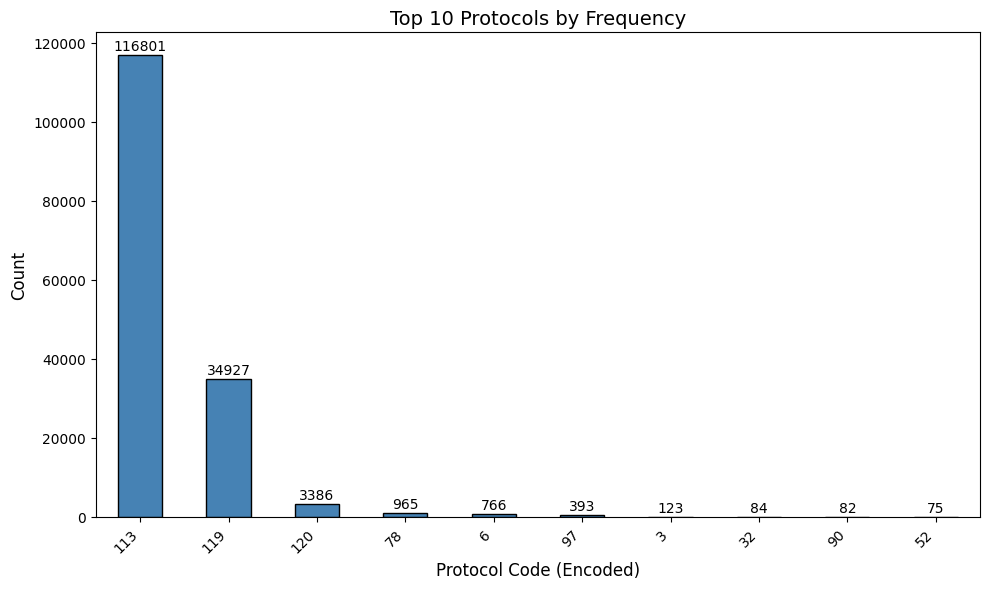

In [ ]:
import matplotlib.pyplot as plt

# Sort by frequency
proto_counts = df['proto'].value_counts().head(10)  # top 10 protocols for clarity

plt.figure(figsize=(10,6))
proto_counts.plot(kind='bar', color='steelblue', edgecolor='black')

plt.title("Top 10 Protocols by Frequency", fontsize=14)
plt.xlabel("Protocol Code (Encoded)", fontsize=12)
plt.ylabel("Count", fontsize=12)

# Add value labels
for i, count in enumerate(proto_counts.values):
    plt.text(i, count + 500, str(count), ha='center', va='bottom', fontsize=10)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


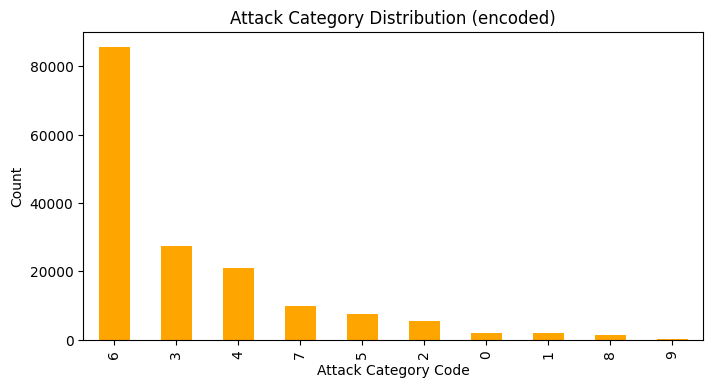

In [ ]:
plt.figure(figsize=(8,4))
df['attack_cat'].value_counts().plot(kind='bar', color='orange')
plt.title("Attack Category Distribution (encoded)")
plt.xlabel("Attack Category Code")
plt.ylabel("Count")
plt.show()

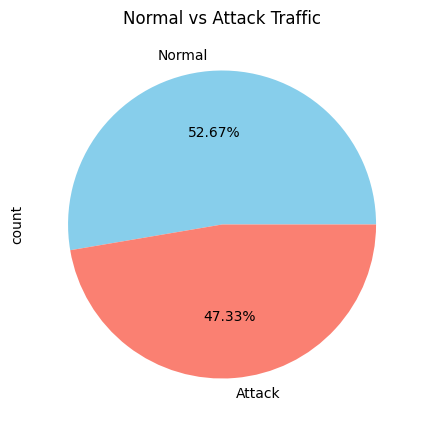

In [ ]:
df['label'].value_counts().plot(kind='pie', autopct='%1.2f%%', labels=['Normal', 'Attack'], figsize=(5,5), colors=['skyblue','salmon'])
plt.title("Normal vs Attack Traffic")
plt.show()

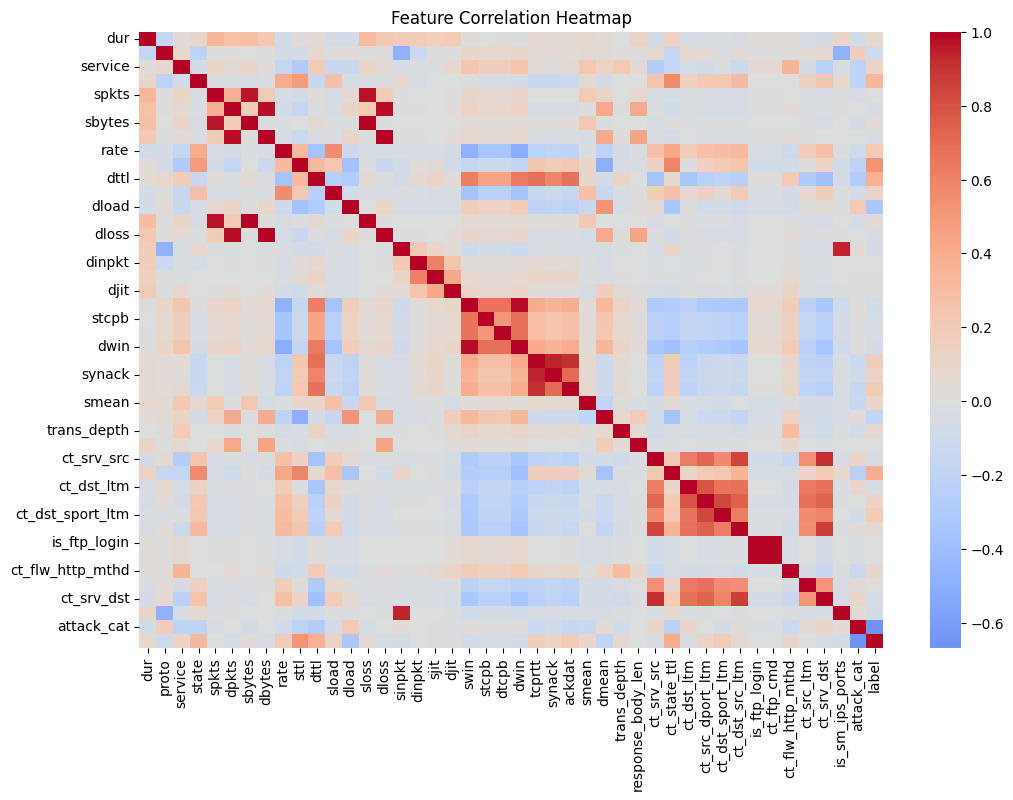

In [ ]:
import seaborn as sns

plt.figure(figsize=(12,8))
corr_matrix = df.corr(numeric_only=True)
sns.heatmap(corr_matrix, cmap='coolwarm', center=0)
plt.title("Feature Correlation Heatmap")
plt.show()

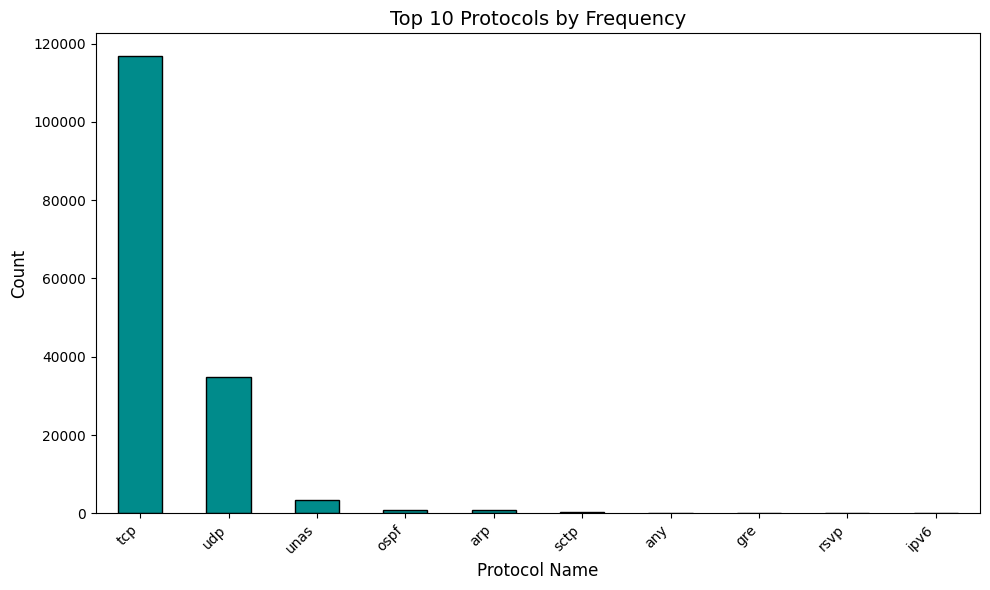

In [ ]:
plt.figure(figsize=(10,6))
df_raw['proto'].value_counts().head(10).plot(kind='bar', color='darkcyan', edgecolor='black')

plt.title("Top 10 Protocols by Frequency", fontsize=14)
plt.xlabel("Protocol Name", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

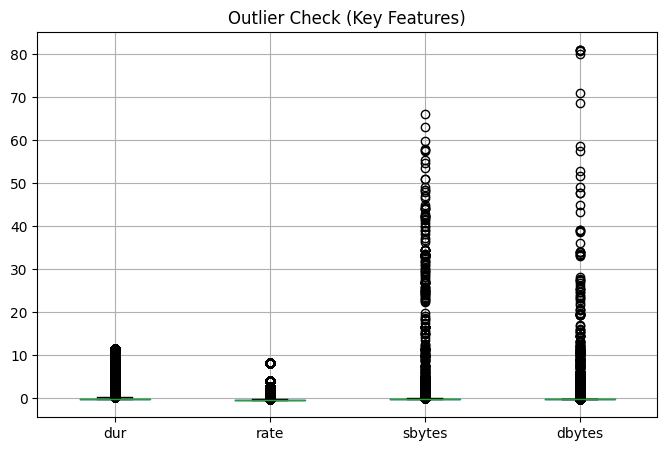

✅ EDA complete.


In [ ]:
numeric_sample = ['dur', 'rate', 'sbytes', 'dbytes']
df[numeric_sample].boxplot(figsize=(8,5))
plt.title("Outlier Check (Key Features)")
plt.show()

print("✅ EDA complete.")

PRE-PROCESSING AND FEATURE EXTRACTION:

In [ ]:
protocols_of_interest = ['tcp', 'udp', 'icmp']
df_filtered = df_raw[df_raw['proto'].isin(protocols_of_interest)].copy()

# Print counts per protocol
print(df_filtered['proto'].value_counts())

proto
tcp     116801
udp      34927
icmp        13
Name: count, dtype: int64


In [ ]:
# Common features across all protocols
common_features = ['dur', 'sbytes', 'dbytes', 'spkts', 'dpkts', 'rate']

# TCP-specific features
tcp_features = common_features + ['sttl', 'dttl', 'tcprtt', 'synack', 'ackdat']

# UDP-specific features
udp_features = common_features + ['sttl', 'dttl']

# ICMP-specific features
icmp_features = common_features + ['sttl', 'dttl']

# Create per-protocol DataFrames
df_tcp  = df_filtered[df_filtered['proto'] == 'tcp'][tcp_features]
df_udp  = df_filtered[df_filtered['proto'] == 'udp'][udp_features]
df_icmp = df_filtered[df_filtered['proto'] == 'icmp'][icmp_features]

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
tcp_scaled  = scaler.fit_transform(df_tcp)
udp_scaled  = scaler.fit_transform(df_udp)
icmp_scaled = scaler.fit_transform(df_icmp)

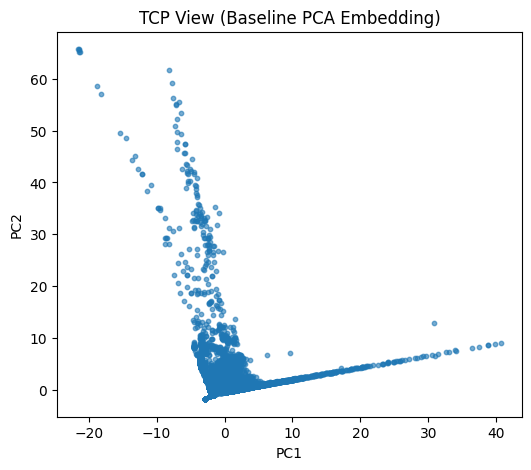

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Fit PCA for each view
pca = PCA(n_components=2)
tcp_pca  = pca.fit_transform(tcp_scaled)
udp_pca  = pca.fit_transform(udp_scaled)
icmp_pca = pca.fit_transform(icmp_scaled)

# Visualize example (TCP)
plt.figure(figsize=(6,5))
plt.scatter(tcp_pca[:,0], tcp_pca[:,1], s=10, alpha=0.6)
plt.title("TCP View (Baseline PCA Embedding)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [ ]:
import numpy as np
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, concatenate

# Concatenate all protocol views (align feature dimensions by padding with zeros)
max_dim = max(tcp_scaled.shape[1], udp_scaled.shape[1], icmp_scaled.shape[1])

def pad_features(X, target_dim):
    pad_width = target_dim - X.shape[1]
    return np.pad(X, ((0,0), (0,pad_width)), 'constant')

tcp_padded  = pad_features(tcp_scaled, max_dim)
udp_padded  = pad_features(udp_scaled, max_dim)
icmp_padded = pad_features(icmp_scaled, max_dim)

# Combine all into one dataset for joint embedding
X_all = np.vstack([tcp_padded, udp_padded, icmp_padded])

# Autoencoder architecture
input_dim = X_all.shape[1]
encoding_dim = 10  # latent size

input_layer = Input(shape=(input_dim,))
encoded = Dense(32, activation='relu')(input_layer)
encoded = Dense(encoding_dim, activation='relu')(encoded)
decoded = Dense(32, activation='relu')(encoded)
decoded = Dense(input_dim, activation='linear')(decoded)

autoencoder = Model(input_layer, decoded)
encoder = Model(input_layer, encoded)

autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.fit(X_all, X_all, epochs=10, batch_size=512, shuffle=True, verbose=1)

# Extract shared embeddings
shared_embeddings = encoder.predict(X_all)
print("✅ Shared latent feature space created:", shared_embeddings.shape)

Epoch 1/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.5278
Epoch 2/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0623
Epoch 3/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0230
Epoch 4/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0155
Epoch 5/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0099
Epoch 6/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0065
Epoch 7/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0054
Epoch 8/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0044
Epoch 9/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0038
Epoch 10/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0034
4742/4742 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step
✅ Shared latent feature space created: (151741, 10)


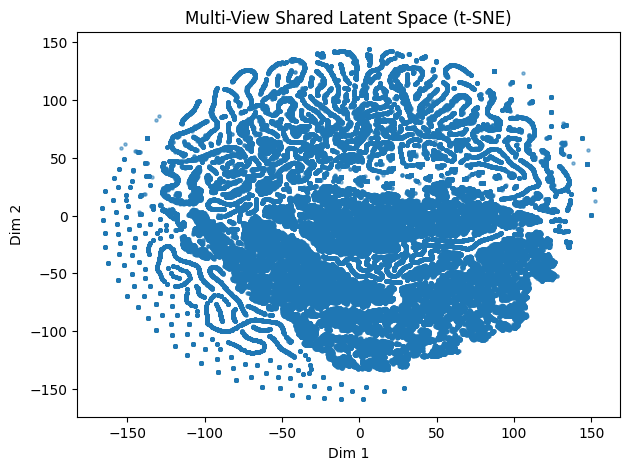

In [ ]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
tsne_embedded = tsne.fit_transform(shared_embeddings)

plt.figure(figsize=(7,5))
plt.scatter(tsne_embedded[:,0], tsne_embedded[:,1], s=5, alpha=0.5)
plt.title("Multi-View Shared Latent Space (t-SNE)")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.show()

Model Building & Anomaly Detection


🔹 Clustering TCP view...


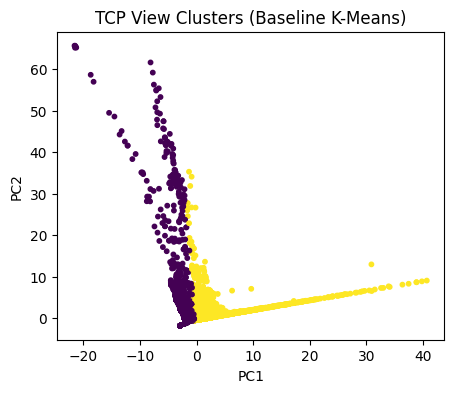


🔹 Clustering UDP view...


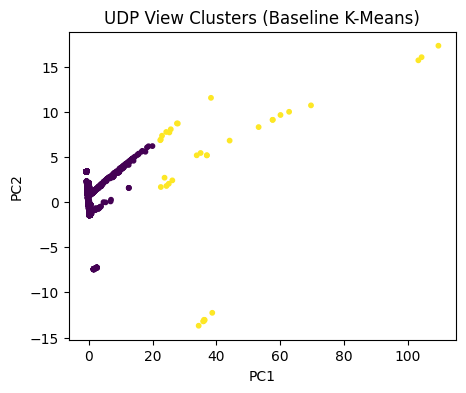


🔹 Clustering ICMP view...


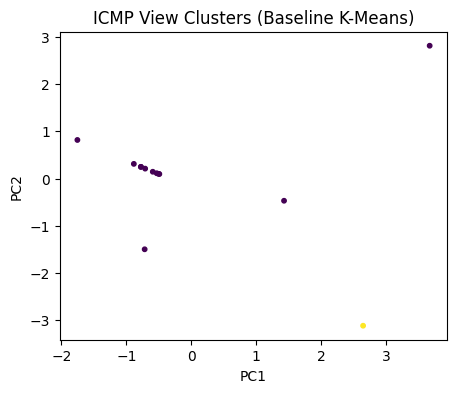

✅ Baseline single-view clustering complete.


In [ ]:
# ---- BASELINE SINGLE-VIEW CLUSTERING ----
from sklearn.cluster import KMeans
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
import numpy as np
import matplotlib.pyplot as plt

# Example: use the PCA embeddings we computed earlier
# tcp_pca, udp_pca, icmp_pca from Step 3
protocol_views = {
    "TCP": tcp_pca,
    "UDP": udp_pca,
    "ICMP": icmp_pca
}

results_baseline = {}

for proto, X in protocol_views.items():
    print(f"\n🔹 Clustering {proto} view...")

    # 1️⃣ Fit K-Means
    kmeans = KMeans(n_clusters=2, random_state=42)
    cluster_labels = kmeans.fit_predict(X)

    # 2️⃣ Compute anomaly score = distance from cluster center
    distances = np.min(kmeans.transform(X), axis=1)
    threshold = np.percentile(distances, 95)  # top 5% farthest points as anomalies
    anomalies = (distances > threshold).astype(int)

    # 3️⃣ Save results
    results_baseline[proto] = {
        "cluster_labels": cluster_labels,
        "anomaly_labels": anomalies,
        "distances": distances
    }

    # 4️⃣ Plot clusters
    plt.figure(figsize=(5,4))
    plt.scatter(X[:,0], X[:,1], c=cluster_labels, cmap='viridis', s=10)
    plt.title(f"{proto} View Clusters (Baseline K-Means)")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.show()

print("✅ Baseline single-view clustering complete.")


In [ ]:
# ---- MULTI-VIEW SHARED EMBEDDING ----
from sklearn.mixture import GaussianMixture
from sklearn.ensemble import IsolationForest

# X_all = combined padded TCP/UDP/ICMP data
# shared_embeddings = encoder.predict(X_all)

print("\n🔹 Clustering shared latent space...")

# 1️⃣ Apply Gaussian Mixture Model (GMM)
gmm = GaussianMixture(n_components=2, covariance_type='full', random_state=42)
gmm_labels = gmm.fit_predict(shared_embeddings)
gmm_scores = -gmm.score_samples(shared_embeddings)

# 2️⃣ Alternatively, use Isolation Forest for anomaly detection
iso = IsolationForest(contamination=0.05, random_state=42)
iso_labels = iso.fit_predict(shared_embeddings)
iso_labels = np.where(iso_labels == -1, 1, 0)  # convert -1 → anomaly (1)

# 3️⃣ Combine both if desired (ensemble)
final_anomaly_score = (0.5 * (gmm_scores - gmm_scores.min()) /
                       (gmm_scores.max() - gmm_scores.min()) +
                       0.5 * iso_labels)

# 4️⃣ Thresholding (top 5% anomalies)
threshold_mv = np.percentile(final_anomaly_score, 95)
multi_view_anomalies = (final_anomaly_score > threshold_mv).astype(int)

print("✅ Multi-view clustering complete. Shared latent anomalies computed.")



🔹 Clustering shared latent space...
✅ Multi-view clustering complete. Shared latent anomalies computed.


In [ ]:
# Extract ground truth
y_true = df_filtered['label'].values[:len(shared_embeddings)]  # ensure alignment

# Evaluate Multi-view model
precision = precision_score(y_true, multi_view_anomalies)
recall = recall_score(y_true, multi_view_anomalies)
f1 = f1_score(y_true, multi_view_anomalies)
auc = roc_auc_score(y_true, final_anomaly_score)

print("\n📊 Multi-view Performance:")
print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1-score:  {f1:.3f}")
print(f"AUC:       {auc:.3f}")



📊 Multi-view Performance:
Precision: 0.410
Recall:    0.047
F1-score:  0.084
AUC:       0.515


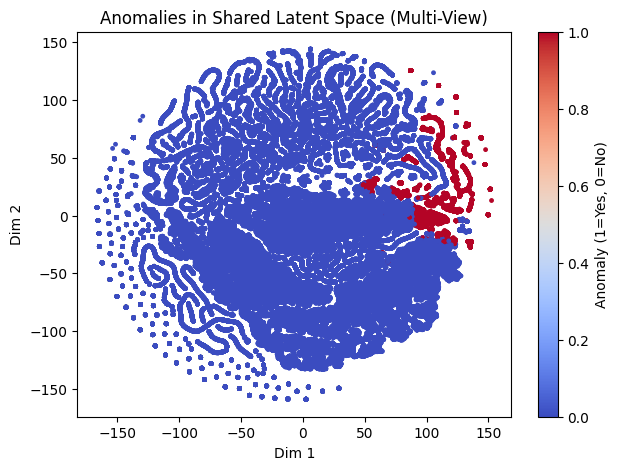

In [ ]:
plt.figure(figsize=(7,5))
plt.scatter(tsne_embedded[:,0], tsne_embedded[:,1],
            c=multi_view_anomalies, cmap='coolwarm', s=6)
plt.title("Anomalies in Shared Latent Space (Multi-View)")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.colorbar(label="Anomaly (1=Yes, 0=No)")
plt.show()


🚨 Unique anomalies detected only by multi-view: 1159


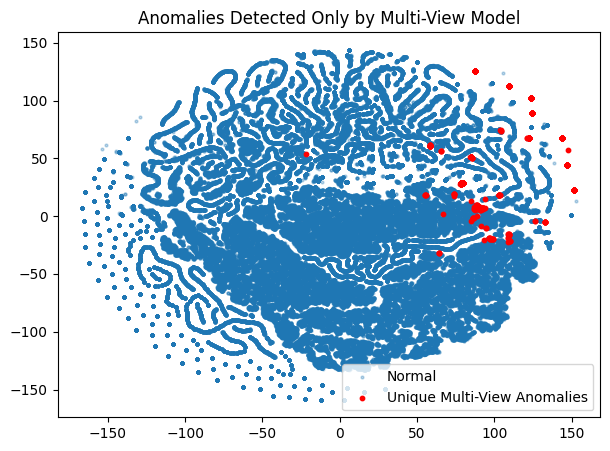

In [ ]:
# Compare anomaly overlap (assuming same ordering)
baseline_combined = np.concatenate([
    results_baseline["TCP"]["anomaly_labels"],
    results_baseline["UDP"]["anomaly_labels"],
    results_baseline["ICMP"]["anomaly_labels"]
])[:len(multi_view_anomalies)]

unique_anomalies = np.where((multi_view_anomalies == 1) & (baseline_combined == 0))[0]

print(f"🚨 Unique anomalies detected only by multi-view: {len(unique_anomalies)}")

# Plot those points in latent space
plt.figure(figsize=(7,5))
plt.scatter(tsne_embedded[:,0], tsne_embedded[:,1], s=4, alpha=0.3, label='Normal')
plt.scatter(tsne_embedded[unique_anomalies,0],
            tsne_embedded[unique_anomalies,1],
            color='red', s=10, label='Unique Multi-View Anomalies')
plt.legend()
plt.title("Anomalies Detected Only by Multi-View Model")
plt.show()


EVALUATION

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

# Extract ground truth labels (ensure alignment)
y_true = df_filtered['label'].values[:len(shared_embeddings)]

# ---- Baseline Metrics (combine all single-view anomalies) ----
baseline_anomalies = np.concatenate([
    results_baseline["TCP"]["anomaly_labels"],
    results_baseline["UDP"]["anomaly_labels"],
    results_baseline["ICMP"]["anomaly_labels"]
])[:len(y_true)]

precision_base = precision_score(y_true, baseline_anomalies)
recall_base    = recall_score(y_true, baseline_anomalies)
f1_base        = f1_score(y_true, baseline_anomalies)
auc_base       = roc_auc_score(y_true, baseline_anomalies)

# ---- Multi-view Metrics ----
precision_mv = precision_score(y_true, multi_view_anomalies)
recall_mv    = recall_score(y_true, multi_view_anomalies)
f1_mv        = f1_score(y_true, multi_view_anomalies)
auc_mv       = roc_auc_score(y_true, final_anomaly_score)

# ---- Compare Results ----
import pandas as pd

metrics_df = pd.DataFrame({
    "Metric": ["Precision", "Recall", "F1-score", "AUC"],
    "Baseline (Single-view)": [precision_base, recall_base, f1_base, auc_base],
    "Proposed (Multi-view)":  [precision_mv, recall_mv, f1_mv, auc_mv]
})

print("📊 Model Comparison:")
print(metrics_df)


📊 Model Comparison:
      Metric  Baseline (Single-view)  Proposed (Multi-view)
0  Precision                0.426133               0.410175
1     Recall                0.047378               0.046512
2   F1-score                0.085276               0.083549
3        AUC                0.498528               0.515449


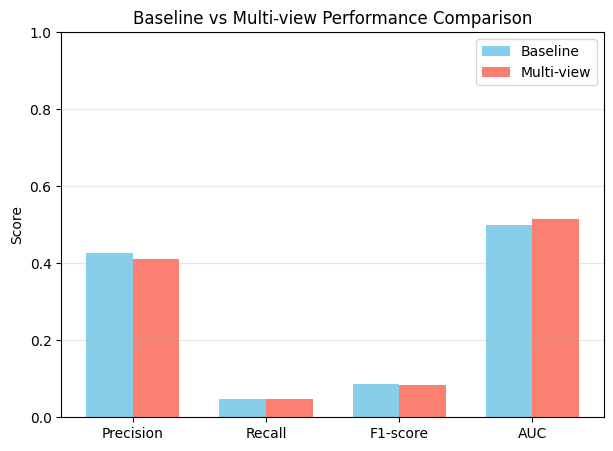

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(7,5))
x = np.arange(len(metrics_df))
width = 0.35

plt.bar(x - width/2, metrics_df["Baseline (Single-view)"], width, label='Baseline', color='skyblue')
plt.bar(x + width/2, metrics_df["Proposed (Multi-view)"], width, label='Multi-view', color='salmon')

plt.xticks(x, metrics_df["Metric"])
plt.ylabel("Score")
plt.title("Baseline vs Multi-view Performance Comparison")
plt.ylim(0, 1)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()


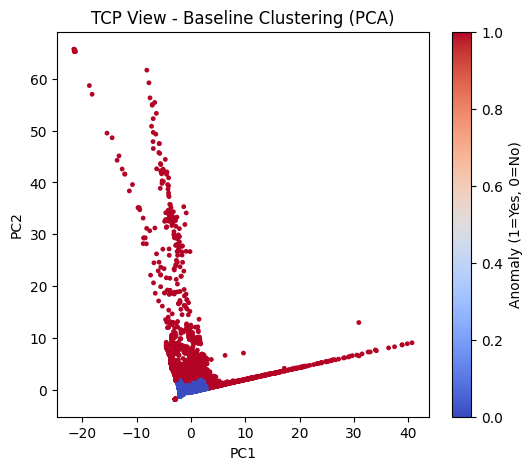

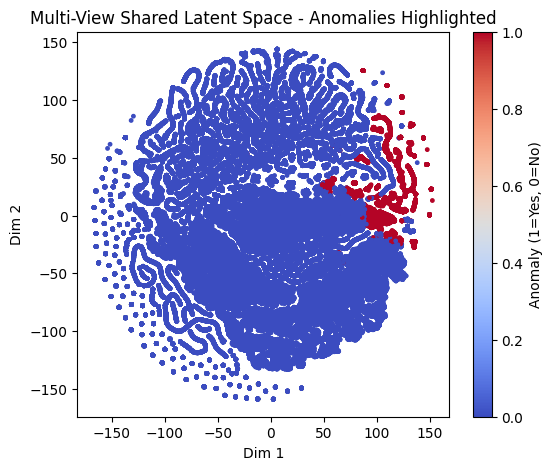

In [ ]:
# Plot baseline TCP view (example)
plt.figure(figsize=(6,5))
plt.scatter(tcp_pca[:,0], tcp_pca[:,1],
            c=results_baseline["TCP"]["anomaly_labels"], cmap='coolwarm', s=6)
plt.title("TCP View - Baseline Clustering (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="Anomaly (1=Yes, 0=No)")
plt.show()

# Plot multi-view shared latent space
plt.figure(figsize=(6,5))
plt.scatter(tsne_embedded[:,0], tsne_embedded[:,1],
            c=multi_view_anomalies, cmap='coolwarm', s=6)
plt.title("Multi-View Shared Latent Space - Anomalies Highlighted")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.colorbar(label="Anomaly (1=Yes, 0=No)")
plt.show()


🚨 Unique anomalies detected only by Multi-view model: 1159


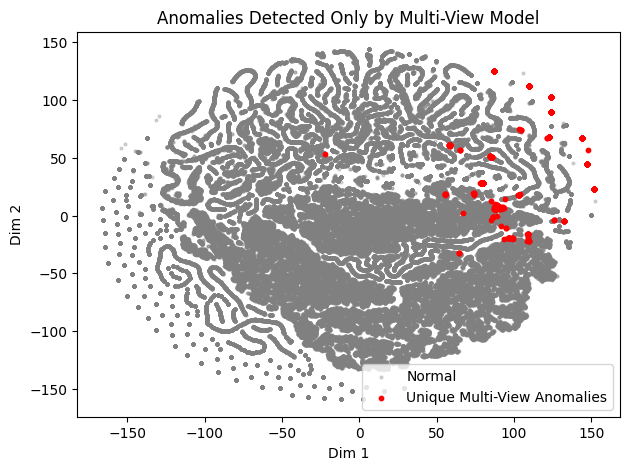

In [ ]:
# Find anomalies unique to the multi-view model
unique_anomalies = np.where((multi_view_anomalies == 1) & (baseline_anomalies == 0))[0]

print(f"🚨 Unique anomalies detected only by Multi-view model: {len(unique_anomalies)}")

# Plot unique anomalies in latent space
plt.figure(figsize=(7,5))
plt.scatter(tsne_embedded[:,0], tsne_embedded[:,1],
            s=4, alpha=0.3, label='Normal', color='gray')
plt.scatter(tsne_embedded[unique_anomalies,0],
            tsne_embedded[unique_anomalies,1],
            color='red', s=10, label='Unique Multi-View Anomalies')
plt.legend()
plt.title("Anomalies Detected Only by Multi-View Model")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.show()


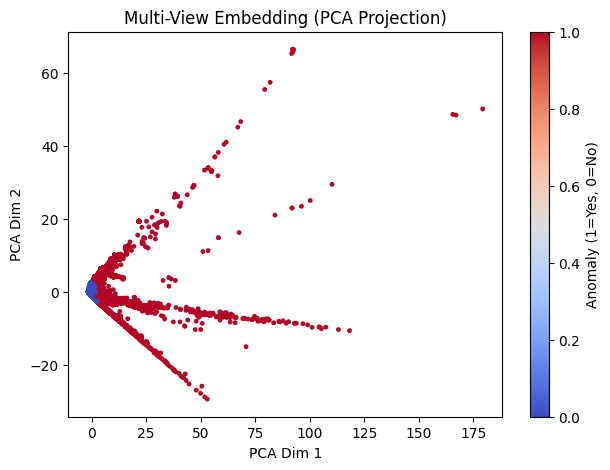

In [ ]:
from sklearn.decomposition import PCA

pca_2d = PCA(n_components=2)
pca_embedded = pca_2d.fit_transform(shared_embeddings)

plt.figure(figsize=(7,5))
plt.scatter(pca_embedded[:,0], pca_embedded[:,1],
            c=multi_view_anomalies, cmap='coolwarm', s=6)
plt.title("Multi-View Embedding (PCA Projection)")
plt.xlabel("PCA Dim 1")
plt.ylabel("PCA Dim 2")
plt.colorbar(label="Anomaly (1=Yes, 0=No)")
plt.show()


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(


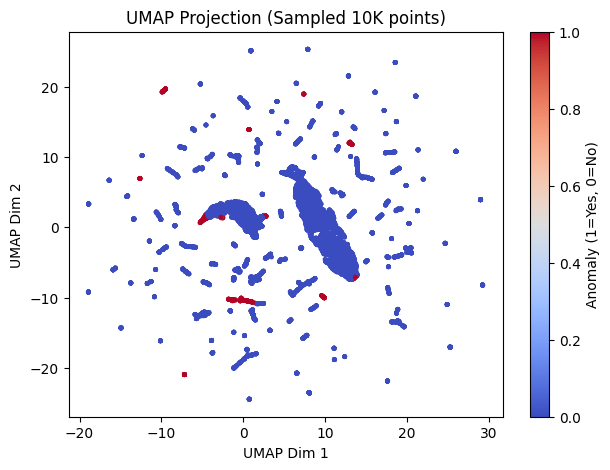

In [ ]:
import numpy as np

# Sample 10,000 points for faster UMAP visualization
idx = np.random.choice(len(shared_embeddings), size=10000, replace=False)
sampled_embeddings = shared_embeddings[idx]
sampled_anomalies = multi_view_anomalies[idx]

# Run UMAP on sampled data
import umap.umap_ as umap

umap_2d = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
umap_embedded = umap_2d.fit_transform(sampled_embeddings)

plt.figure(figsize=(7,5))
plt.scatter(umap_embedded[:,0], umap_embedded[:,1],
            c=sampled_anomalies, cmap='coolwarm', s=6)
plt.title("UMAP Projection (Sampled 10K points)")
plt.xlabel("UMAP Dim 1")
plt.ylabel("UMAP Dim 2")
plt.colorbar(label="Anomaly (1=Yes, 0=No)")
plt.show()


In [ ]:
print(multi_view_anomalies[:10])
print(type(multi_view_anomalies))


[0 0 0 0 0 0 0 0 0 0]
<class 'numpy.ndarray'>


In [ ]:
from sklearn.mixture import GaussianMixture
from sklearn.ensemble import IsolationForest

# Shared latent space
shared_embeddings

# GMM
gmm = GaussianMixture(n_components=2, random_state=42) # Re-initialize with random_state for reproducibility
gmm.fit(shared_embeddings) # Fit the GMM model
gmm_scores = -gmm.score_samples(shared_embeddings)

# Normalize gmm_scores
normalized_gmm = (gmm_scores - gmm_scores.min()) / (gmm_scores.max() - gmm_scores.min())

# Isolation Forest
iso = IsolationForest(contamination=0.05, random_state=42) # Re-initialize with random_state for reproducibility
iso_labels = iso.fit_predict(shared_embeddings)
iso_labels = np.where(iso_labels == -1, 1, 0) # convert -1 -> anomaly (1)

# Ensemble anomaly score
final_anomaly_score = 0.5 * normalized_gmm + 0.5 * iso_labels

# Define threshold based on previous cell's logic
threshold_mv = np.percentile(final_anomaly_score, 95)

# Final anomalies
multi_view_anomalies = (final_anomaly_score > threshold_mv).astype(int)

In [ ]:
def mv_anomaly_score_fn(X):
    gmm = GaussianMixture(n_components=2, random_state=42)
    gmm_scores = -gmm.fit(X).score_samples(X)

    iso = IsolationForest(contamination=0.05, random_state=42)
    iso_labels = iso.fit_predict(X)
    iso_labels = np.where(iso_labels == -1, 1, 0)

    score = 0.5 * (gmm_scores - gmm_scores.min()) / (gmm_scores.max() - gmm_scores.min()) \
            + 0.5 * iso_labels
    return score


In [ ]:
from sklearn.metrics import roc_auc_score

def view_ablation_score(protocol_views, original_scores):
    scores = {}

    for view_to_remove in protocol_views:
        reduced = {k:v for k,v in protocol_views.items() if k!=view_to_remove}
        X_reduced = np.hstack(list(reduced.values()))

        new_scores = mv_anomaly_score_fn(X_reduced)
        scores[view_to_remove] = roc_auc_score(
            (original_scores > np.percentile(original_scores,95)).astype(int),
            new_scores
        )

    return scores


In [ ]:
from sklearn.ensemble import RandomForestRegressor

surrogate = RandomForestRegressor(
    n_estimators=200,
    max_depth=6,
    random_state=42
)

surrogate.fit(shared_embeddings, final_anomaly_score)


RandomForestRegressor(max_depth=6, n_estimators=200, random_state=42)

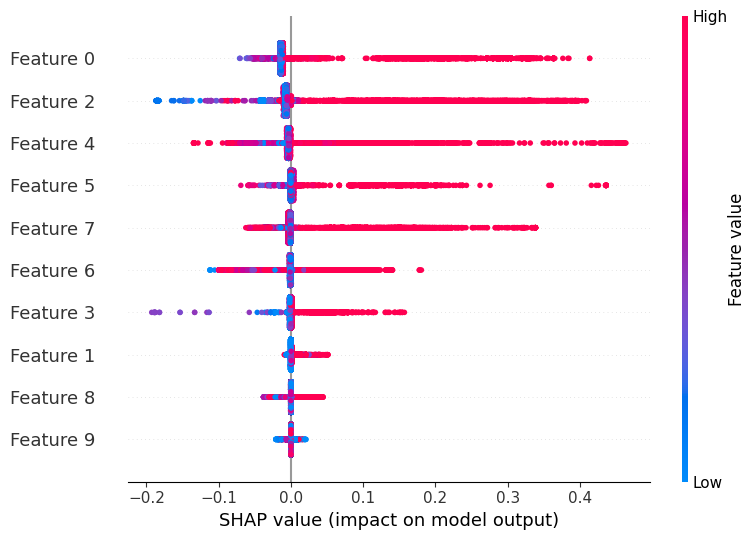

In [ ]:
import shap

explainer = shap.TreeExplainer(surrogate)
shap_values = explainer.shap_values(shared_embeddings)

shap.summary_plot(shap_values, shared_embeddings)


In [ ]:
# Define the latent dimensions for each protocol view (heuristically for demonstration)
# In a simple autoencoder, the shared latent space (encoding_dim=10) is not inherently split by protocol.
# This division is arbitrary to allow the calculation of 'view importance' from the shared latent features.
tcp_latent_dim = 4
udp_latent_dim = 3
icmp_latent_dim = 3

view_dims = {
    "TCP": tcp_latent_dim,
    "UDP": udp_latent_dim,
    "ICMP": icmp_latent_dim
}

start = 0
view_importance = {}

for view, dim in view_dims.items():
    end = start + dim
    # Ensure we don't go out of bounds of shap_values (which has 10 columns)
    if end > shap_values.shape[1]:
        end = shap_values.shape[1]
    if start < shap_values.shape[1]: # Only process if there are columns left
        view_importance[view] = np.mean(np.abs(shap_values[:, start:end]))
    start = end

print(view_importance)

{'TCP': np.float64(0.008718895806107239), 'UDP': np.float64(0.00481125583759884), 'ICMP': np.float64(0.001077172231433299)}


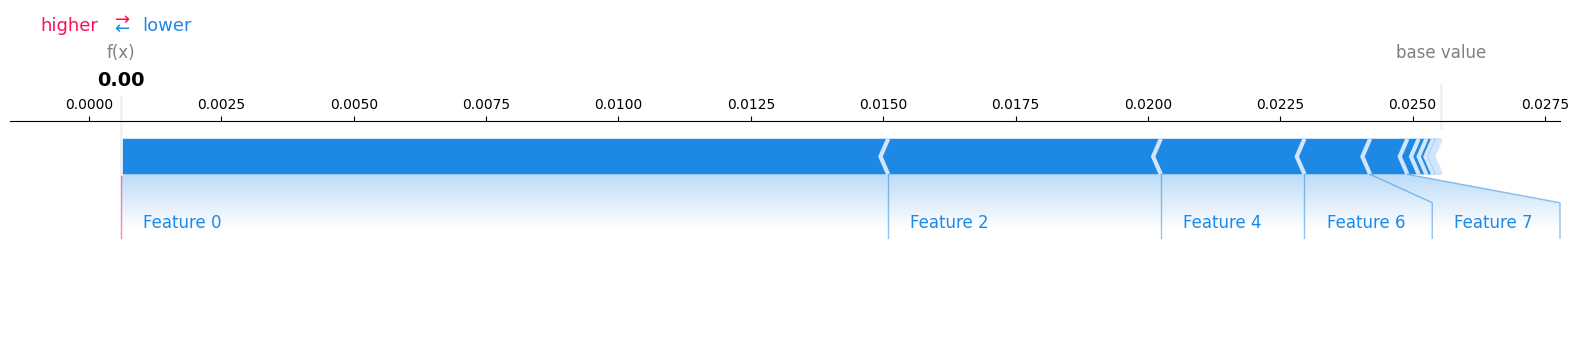

In [ ]:
idx = 10

shap.force_plot(
    explainer.expected_value,
    shap_values[idx],
    matplotlib=True
)


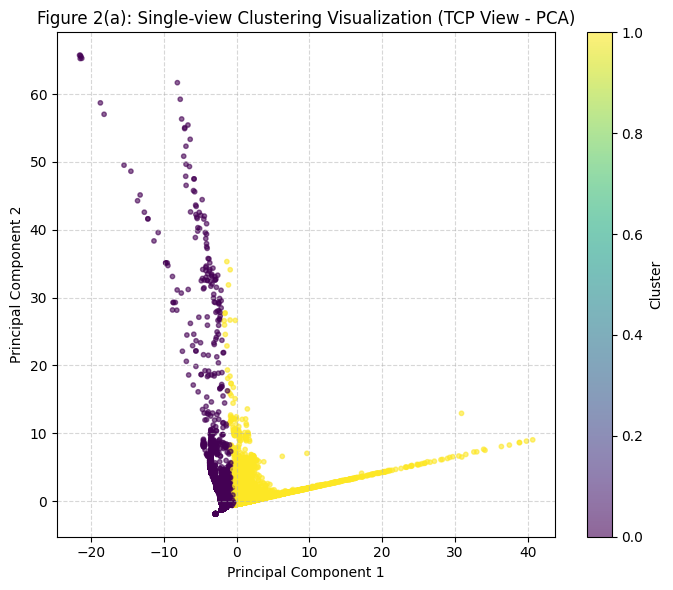

In [ ]:
import matplotlib.pyplot as plt

# Figure 2(a): Single-view clustering visualization (e.g., TCP view PCA)
plt.figure(figsize=(7,6))
plt.scatter(tcp_pca[:,0], tcp_pca[:,1], c=results_baseline["TCP"]["cluster_labels"], cmap='viridis', s=10, alpha=0.6)
plt.title("Figure 2(a): Single-view Clustering Visualization (TCP View - PCA)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label="Cluster")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Figure 2. (b) Multi-view clustering visualization
This second figure displays the multi-view clustering in the shared latent space, visualized using t-SNE. Here, you should be able to see how the multi-view approach groups data points into more distinct and separated clusters.

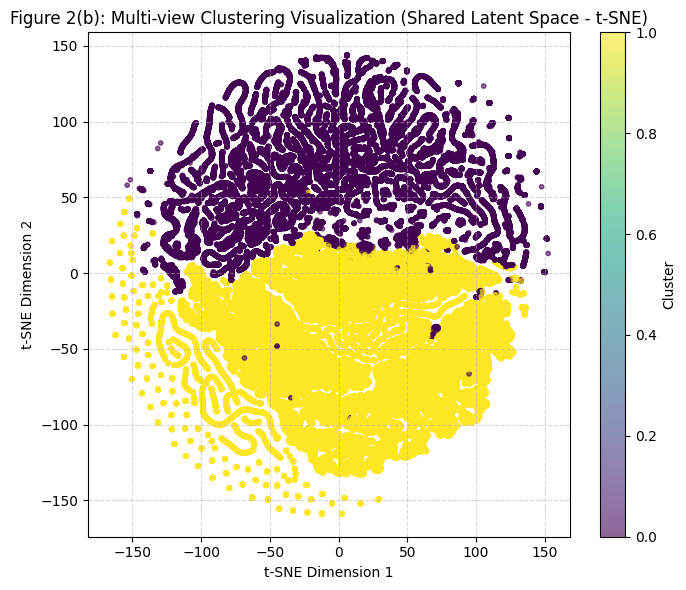

In [ ]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# Re-run t-SNE for consistent visualization with latest state if needed
# Note: t-SNE is a non-deterministic algorithm, so re-running might slightly change the layout
# For exact reproducibility, the `tsne_embedded` from the earlier execution should be used if available and unchanged.

# Assuming tsne_embedded and gmm_labels are available from previous execution
# If not, ensure these steps are run first:
# tsne = TSNE(n_components=2, perplexity=30, random_state=42)
# tsne_embedded = tsne.fit_transform(shared_embeddings)

# Figure 2(b): Multi-view clustering visualization (t-SNE of shared latent space)
plt.figure(figsize=(7,6))
plt.scatter(tsne_embedded[:,0], tsne_embedded[:,1], c=gmm_labels, cmap='viridis', s=10, alpha=0.6)
plt.title("Figure 2(b): Multi-view Clustering Visualization (Shared Latent Space - t-SNE)")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.colorbar(label="Cluster")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import silhouette_score

# --- Baseline Silhouette Scores (for each single view) ---
silhouette_scores_baseline = {}
for proto, data in protocol_views.items():
    # Use the cluster_labels generated by KMeans in the baseline step
    labels = results_baseline[proto]["cluster_labels"]
    if len(np.unique(labels)) > 1: # Silhouette score requires at least 2 clusters
        try:
            score = silhouette_score(data, labels)
            silhouette_scores_baseline[proto] = score
        except Exception as e:
            print(f"Could not calculate silhouette score for {proto}: {e}")
    else:
        print(f"Skipping silhouette score for {proto}: only one cluster found.")

# For overall baseline, we can average for comparison. Note: This is a simplification.
average_baseline_silhouette = np.mean(list(silhouette_scores_baseline.values()))

print("\nBaseline Single-View Silhouette Scores:")
for proto, score in silhouette_scores_baseline.items():
    print(f"{proto}: {score:.3f}")
print(f"Average Baseline: {average_baseline_silhouette:.3f}")


Baseline Single-View Silhouette Scores:
TCP: 0.672
UDP: 0.961
ICMP: 0.581
Average Baseline: 0.738


In [ ]:
from sklearn.metrics import silhouette_score

# --- Multi-view Silhouette Score ---
# Using the shared_embeddings and gmm_labels from the multi-view clustering
# Ensure there's more than one cluster to calculate silhouette score
if len(np.unique(gmm_labels)) > 1:
    multi_view_silhouette = silhouette_score(shared_embeddings, gmm_labels)
else:
    multi_view_silhouette = np.nan
    print("Skipping multi-view silhouette score: only one cluster found.")

print(f"\nMulti-View (GMM) Silhouette Score: {multi_view_silhouette:.3f}")


Multi-View (GMM) Silhouette Score: 0.402


/tmp/ipython-input-564097181.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Method', y='Silhouette Score', data=df_comparison, palette='viridis')


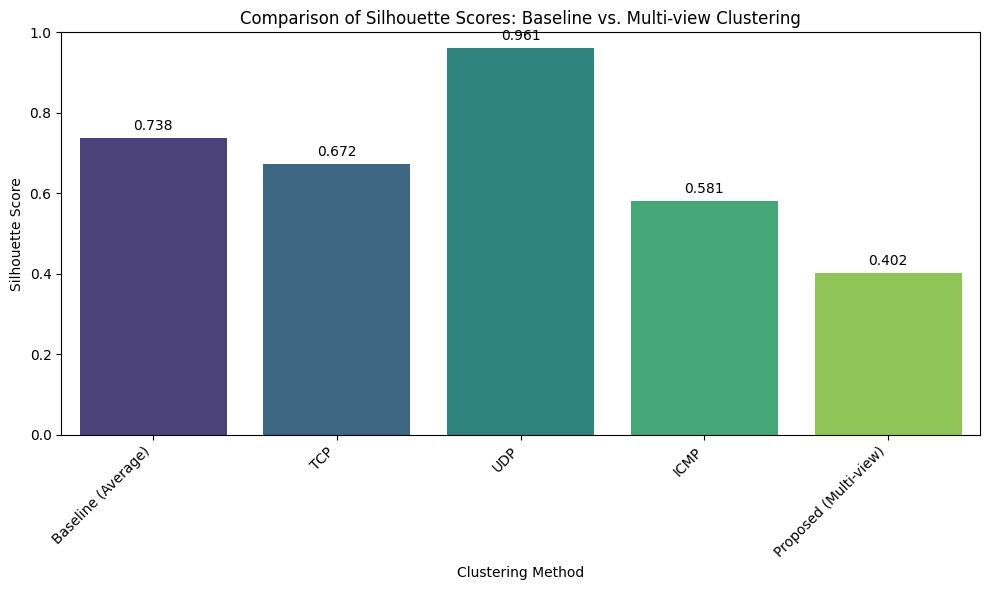


✅ Silhouette score comparison complete.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Prepare data for comparison chart
comparison_data = {
    'Method': ['Baseline (Average)'] + list(silhouette_scores_baseline.keys()) + ['Proposed (Multi-view)'],
    'Silhouette Score': [average_baseline_silhouette] + list(silhouette_scores_baseline.values()) + [multi_view_silhouette]
}
df_comparison = pd.DataFrame(comparison_data)

plt.figure(figsize=(10, 6))
sns.barplot(x='Method', y='Silhouette Score', data=df_comparison, palette='viridis')
plt.title('Comparison of Silhouette Scores: Baseline vs. Multi-view Clustering')
plt.ylabel('Silhouette Score')
plt.xlabel('Clustering Method')
plt.ylim(0, 1) # Silhouette scores typically range from -1 to 1

# Add value labels on top of bars
for index, row in df_comparison.iterrows():
    plt.text(index, row['Silhouette Score'] + 0.02, f"{row['Silhouette Score']:.3f}", color='black', ha="center")

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\n✅ Silhouette score comparison complete.")

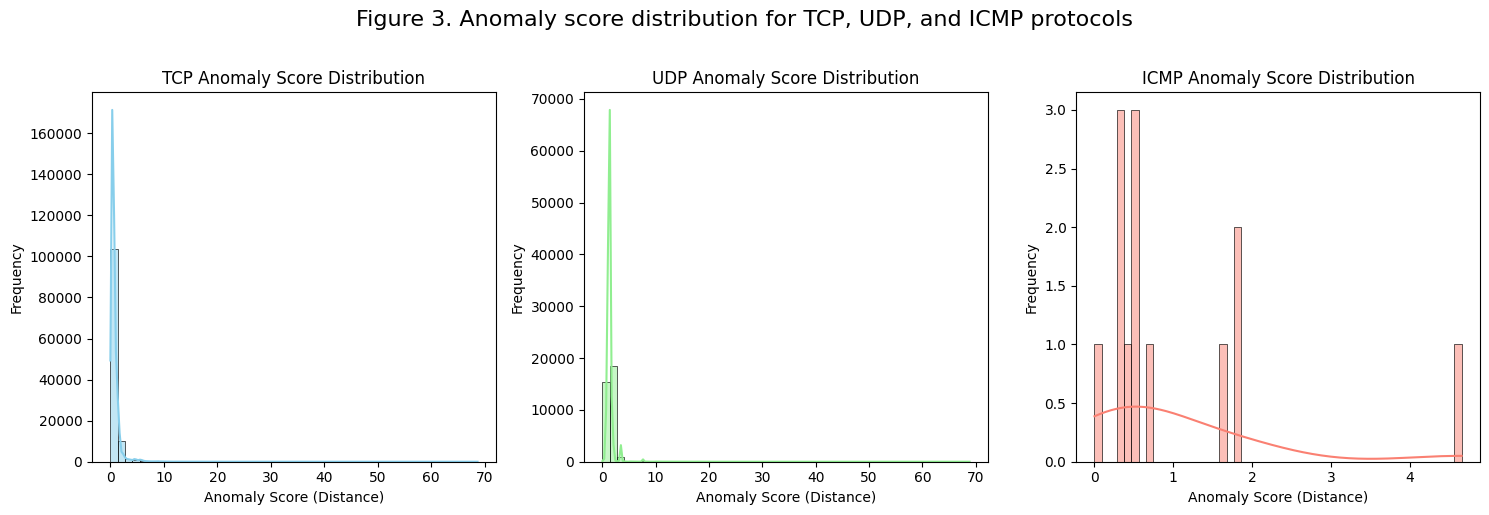

✅ Anomaly score distribution visualization complete.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for plotting
tcp_anomaly_scores = results_baseline["TCP"]["distances"]
udp_anomaly_scores = results_baseline["UDP"]["distances"]
icmp_anomaly_scores = results_baseline["ICMP"]["distances"]

plt.figure(figsize=(15, 5))

# Plot for TCP
plt.subplot(1, 3, 1) # 1 row, 3 columns, 1st plot
sns.histplot(tcp_anomaly_scores, bins=50, kde=True, color='skyblue')
plt.title("TCP Anomaly Score Distribution")
plt.xlabel("Anomaly Score (Distance)")
plt.ylabel("Frequency")

# Plot for UDP
plt.subplot(1, 3, 2) # 1 row, 3 columns, 2nd plot
sns.histplot(udp_anomaly_scores, bins=50, kde=True, color='lightgreen')
plt.title("UDP Anomaly Score Distribution")
plt.xlabel("Anomaly Score (Distance)")
plt.ylabel("Frequency")

# Plot for ICMP
plt.subplot(1, 3, 3) # 1 row, 3 columns, 3rd plot
sns.histplot(icmp_anomaly_scores, bins=50, kde=True, color='salmon')
plt.title("ICMP Anomaly Score Distribution")
plt.xlabel("Anomaly Score (Distance)")
plt.ylabel("Frequency")

plt.suptitle("Figure 3. Anomaly score distribution for TCP, UDP, and ICMP protocols", y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

print("✅ Anomaly score distribution visualization complete.")

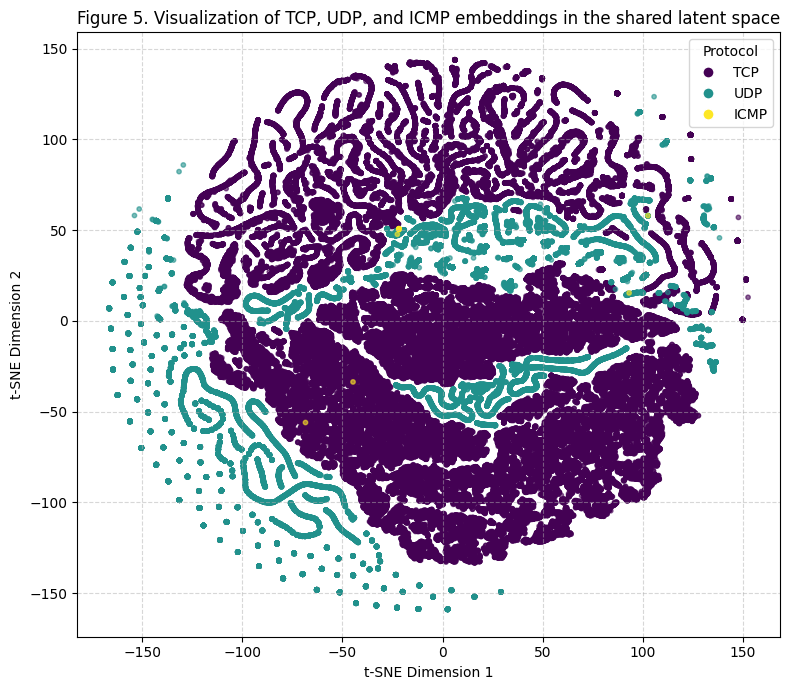

✅ Shared latent space visualization complete.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Get the original lengths of each protocol's dataframes
len_tcp = len(df_tcp)
len_udp = len(df_udp)
len_icmp = len(df_icmp)

# Create an array of labels for each point in the shared_embeddings
# 0 for TCP, 1 for UDP, 2 for ICMP
protocol_labels = np.zeros(len_tcp + len_udp + len_icmp, dtype=int)
protocol_labels[len_tcp : len_tcp + len_udp] = 1
protocol_labels[len_tcp + len_udp : ] = 2

# Use the already computed t-SNE embedding for visualization
# tsne_embedded

plt.figure(figsize=(8, 7))
scatter = plt.scatter(tsne_embedded[:,0], tsne_embedded[:,1], c=protocol_labels,
                      cmap='viridis', s=10, alpha=0.6)

# Create a legend
legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', label='TCP',
               markerfacecolor=scatter.cmap(0/2.0), markersize=8),
    plt.Line2D([0], [0], marker='o', color='w', label='UDP',
               markerfacecolor=scatter.cmap(1/2.0), markersize=8),
    plt.Line2D([0], [0], marker='o', color='w', label='ICMP',
               markerfacecolor=scatter.cmap(2/2.0), markersize=8)
]
plt.legend(handles=legend_elements, title='Protocol')

plt.title("Figure 5. Visualization of TCP, UDP, and ICMP embeddings in the shared latent space")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("✅ Shared latent space visualization complete.")

### Figure 8. Feature-level importance analysis for protocol-specific anomalies.
This figure shows the overall importance of each latent dimension (which act as features in the shared space) in contributing to the anomaly score, as determined by SHAP values. A higher absolute SHAP value indicates a greater impact on the anomaly prediction.

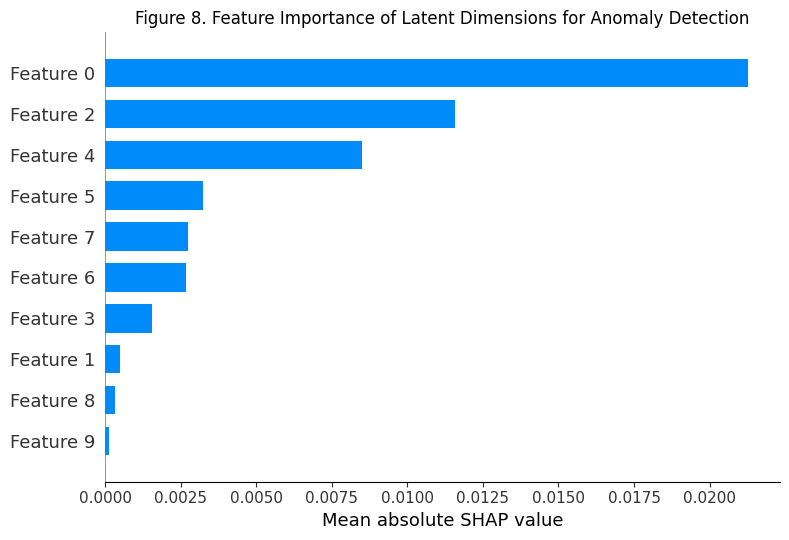

In [ ]:
import shap
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
shap.summary_plot(shap_values, shared_embeddings, plot_type="bar", show=False)
plt.title("Figure 8. Feature Importance of Latent Dimensions for Anomaly Detection")
plt.xlabel("Mean absolute SHAP value")
plt.tight_layout()
plt.show()

### Figure 9. Protocol-level contribution to detected anomalies.
This figure aggregates the importance of latent dimensions back to their originating protocols (based on our heuristic grouping). It shows which protocols collectively have a stronger influence on the overall anomaly detection decision.

/tmp/ipython-input-231969268.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Protocol', y='Importance', data=df_protocol_importance, palette='coolwarm')


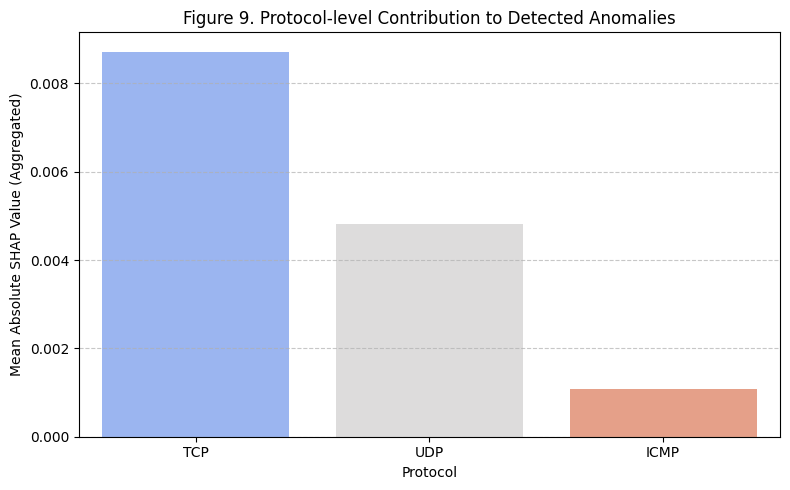

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# 'view_importance' was calculated previously and is available in the kernel state
df_protocol_importance = pd.DataFrame(list(view_importance.items()), columns=['Protocol', 'Importance'])

plt.figure(figsize=(8, 5))
sns.barplot(x='Protocol', y='Importance', data=df_protocol_importance, palette='coolwarm')
plt.title("Figure 9. Protocol-level Contribution to Detected Anomalies")
plt.xlabel("Protocol")
plt.ylabel("Mean Absolute SHAP Value (Aggregated)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Figure 10. Cross-protocol latent dimension contribution analysis.
This figure provides a detailed breakdown of how individual latent dimensions contribute to the anomaly score for a *specific* anomalous instance. It reveals how abnormal relationships or values across protocols (represented in these latent dimensions) drive the anomaly detection.

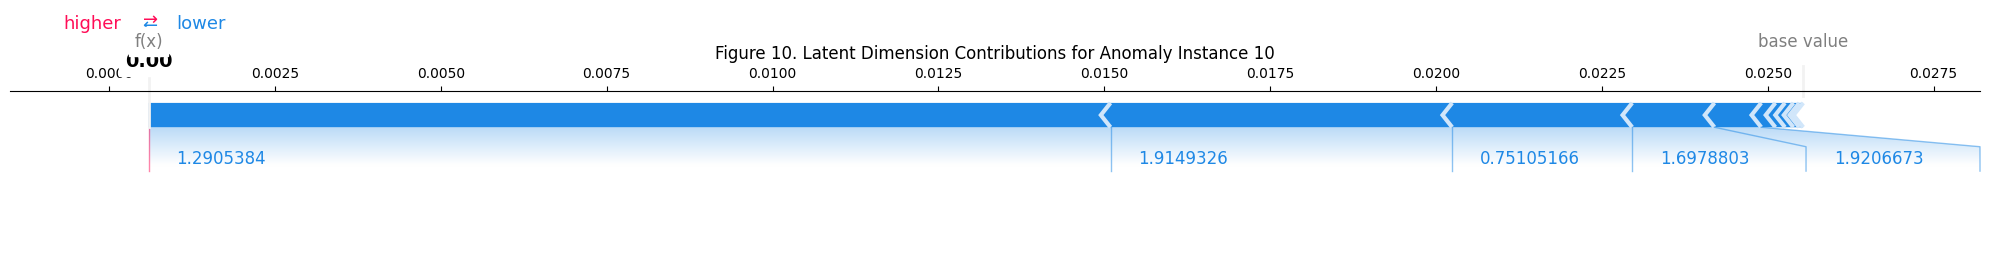

In [ ]:
import shap
import matplotlib.pyplot as plt

# Using an example index (e.g., the 10th data point as done previously)
idx_example_anomaly = 10

# Display the force plot for this instance
shap.force_plot(
    explainer.expected_value,
    shap_values[idx_example_anomaly],
    shared_embeddings[idx_example_anomaly],
    matplotlib=True,
    show=False # set to False to control the plot title and display
)
plt.title(f"Figure 10. Latent Dimension Contributions for Anomaly Instance {idx_example_anomaly}")
plt.tight_layout()
plt.show()

🚨 Unique anomalies detected only by Multi-view model: 1159


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


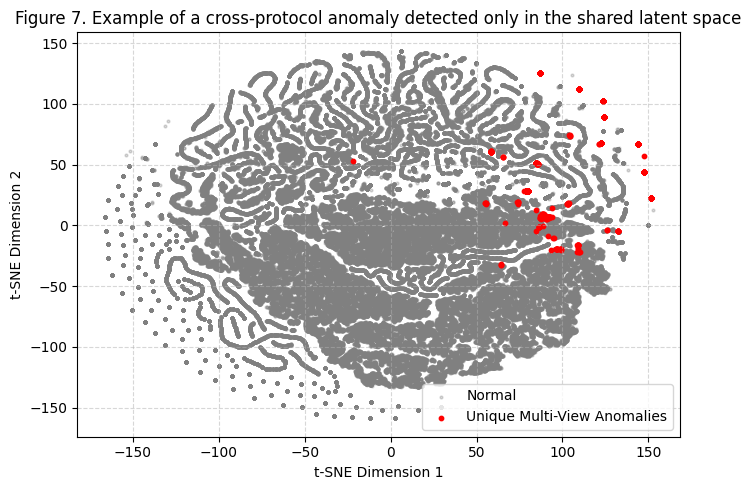

✅ Cross-protocol anomaly visualization complete.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Find anomalies unique to the multi-view model
# Assuming 'multi_view_anomalies' and 'baseline_anomalies' arrays are already available
# from previous execution cells (e.g., in the EVALUATION section)
# If not, these variables would need to be re-calculated or ensured they are in scope.

# 'unique_anomalies' was defined in cell mg638dPOKGGW and re-confirmed in oI727e74LBnI
# It contains indices where multi_view_anomalies == 1 and baseline_anomalies == 0

print(f"🚨 Unique anomalies detected only by Multi-view model: {len(unique_anomalies)}")

# Plot unique anomalies in latent space
plt.figure(figsize=(7,5))
plt.scatter(tsne_embedded[:,0], tsne_embedded[:,1],
            s=4, alpha=0.3, label='Normal', color='gray')
plt.scatter(tsne_embedded[unique_anomalies,0],
            tsne_embedded[unique_anomalies,1],
            color='red', s=10, label='Unique Multi-View Anomalies')
plt.legend()
plt.title("Figure 7. Example of a cross-protocol anomaly detected only in the shared latent space")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("✅ Cross-protocol anomaly visualization complete.")